# Predicting House Prices with Linear Regression

**Objective.** Build and evaluate a linear regression model that predicts house prices from
features such as **area, location, number of rooms, and age** — covering the full pipeline from
data cleaning through to model interpretation.

**Dataset.** `data/house_prices.csv` — an Ames-Housing-style dataset (2,945 rows x 9 columns)
generated by `data/generate_dataset.py`. It mirrors the structure of the Kaggle
*"House Prices: Advanced Regression Techniques"* (Ames) dataset, including real missing values
and a categorical `location` column, so every cleaning step below is genuine rather than cosmetic.

**Tech stack:** Python, pandas, scikit-learn, matplotlib, seaborn.

---

### Pipeline checklist
1. Load & EDA (nulls, descriptive stats, target distribution)
2. Feature-selection discussion
3. Missing-value handling + One-Hot Encoding
4. Correlation heatmap
5. 80/20 train/test split
6. Train Linear Regression
7. Evaluate: MSE, RMSE, R²
8. Actual vs predicted scatter
9. Residual plot
10. Coefficient analysis
11. Bonus: Ridge / Lasso comparison

## 0. Imports & configuration
Pin a random seed so every result is reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

RANDOM_STATE = 42
print("numpy", np.__version__, "| pandas", pd.__version__, "| seaborn", sns.__version__)

numpy 2.5.3 | pandas 3.0.5 | seaborn 0.13.2


## 1. Load the dataset and exploratory data analysis (EDA)

We first load the data and check its shape, data types, and how many values are missing.
`price` is our **target**; everything else is a candidate **feature**.

In [2]:
df = pd.read_csv("../data/house_prices.csv")
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
df.head()

Shape: (2945, 9)

Data types:
 area         float64
location         str
rooms          int64
bathrooms    float64
garage       float64
age          float64
quality        int64
renovated      int64
price          int64
dtype: object


,area,location,rooms,bathrooms,garage,age,quality,renovated,price
0,"1,477.00",Suburb,4,2.20,3.00,15.00,7,0,355200
1,960.00,Waterfront,4,1.00,2.00,60.00,6,0,535800
2,"1,703.00",Downtown,6,1.80,NaN,15.00,7,0,456200
3,"1,810.00",Rural,6,1.80,NaN,5.00,6,1,346100
4,717.00,Suburb,2,1.00,NaN,21.00,3,0,210600


### 1.1 Null-value check
Count and percentage of missing values per column.

In [3]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_report = pd.DataFrame({"missing": null_counts, "pct": null_pct})
null_report = null_report[null_report["missing"] > 0].sort_values("missing", ascending=False)
print("Columns with missing values:\n", null_report.to_string())
print("\nTotal missing cells:", int(null_counts.sum()))

Columns with missing values:
            missing  pct
bathrooms      118 4.01
garage          87 2.95
area            58 1.97
age             43 1.46

Total missing cells: 306


### 1.2 Descriptive statistics
Summary stats for the numeric columns, plus the categorical `location`.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
area,"2,887.00","1,398.07",458.82,417.00,"1,073.00","1,342.00","1,641.00","3,704.00"
rooms,"2,945.00",4.34,1.60,1.00,3.00,4.00,5.00,12.00
bathrooms,"2,827.00",1.60,0.55,1.00,1.10,1.50,1.90,4.30
garage,"2,858.00",2.03,0.85,0.00,1.00,2.00,3.00,4.00
age,"2,902.00",33.15,21.62,0.00,17.00,28.50,44.00,130.00
quality,"2,945.00",6.21,1.47,1.00,5.00,6.00,7.00,10.00
renovated,"2,945.00",0.39,0.49,0.00,0.00,0.00,1.00,1.00
price,"2,945.00","358,466.66","124,856.81","103,500.00","277,700.00","333,500.00","405,100.00","1,071,700.00"


In [5]:
print("Location categories and counts:\n")
print(df["location"].value_counts().to_string())
# Non-numeric columns (works across pandas 2 and 3, where text columns may be 'object' or 'str').
cat_cols = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
print("\nCategorical columns:", cat_cols)

Location categories and counts:

location
Suburb        1239
Downtown       814
Rural          675
Waterfront     217

Categorical columns: ['location']


Notice the **scale mismatch**: `price` is in the hundreds of thousands while `rooms`/`garage`
are single digits. That's fine for plain OLS, but it's why we standardise features for the
regularised models later (so that the penalty is applied fairly across coefficients).

### 1.3 Distribution of the target variable (`price`)

The target distribution matters for linear regression: a strongly skewed target often produces
heteroscedastic residuals (a fan shape), which we will check again on the residual plot.

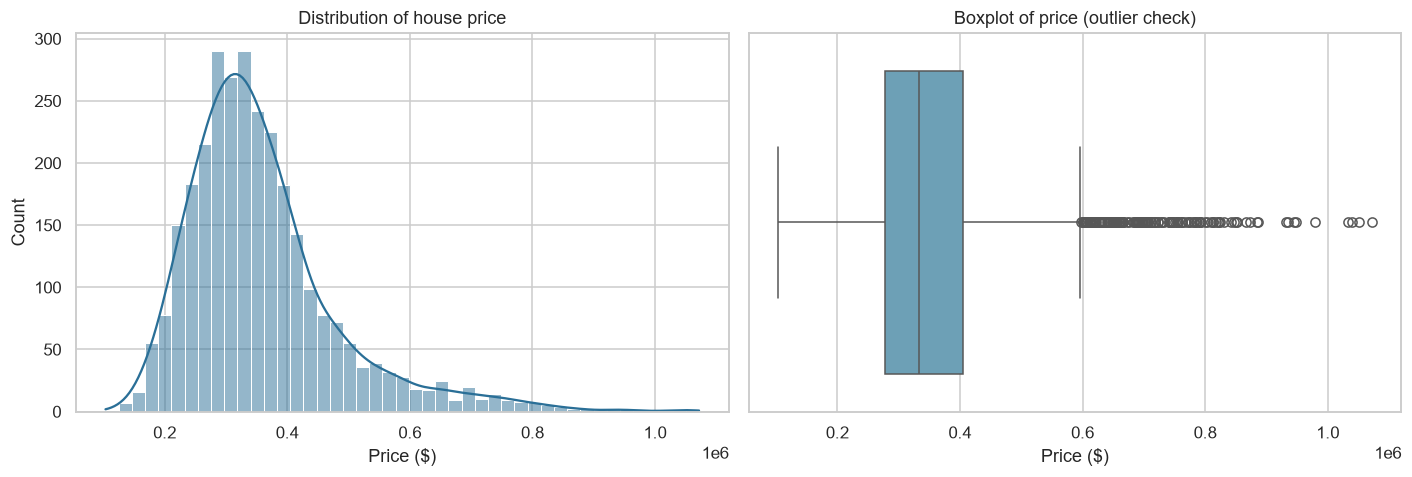

Skewness: 1.563
Kurtosis: 3.643


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["price"], bins=45, kde=True, ax=axes[0], color="#2a6f97")
axes[0].set_title("Distribution of house price")
axes[0].set_xlabel("Price ($)")

sns.boxplot(x=df["price"], ax=axes[1], color="#61a5c2")
axes[1].set_title("Boxplot of price (outlier check)")
axes[1].set_xlabel("Price ($)")

plt.tight_layout()
plt.savefig("../figures/01_price_distribution.png", bbox_inches="tight")
plt.show()

print(f"Skewness: {df['price'].skew():.3f}")
print(f"Kurtosis: {df['price'].kurtosis():.3f}")

**Reading the plot.** The price distribution is mildly right-skewed with a small number of
high-end homes. This is normal for house prices. We keep the outliers for now (they are
plausible real prices, e.g. waterfront properties) but we note that a log-transform of the
target is a common refinement — we touch on it in the conclusions.

## 2. Feature selection discussion

Before modelling, we reason about which features are likely to predict `price`. In linear
regression, "good" predictors are those (a) plausibly related to price, (b) not wildly
redundant with each other (multicollinearity inflates coefficient variance), and (c) available
at prediction time.

| Feature | Type | Expected effect on price | Reasoning |
|---|---|
| `area` | numeric | **Strong +** | Living area is the single most consistent driver of home value; larger homes cost more. |
| `rooms` | numeric | **Moderate +** | More rooms generally means more usable space. But it's *partly redundant with `area`* — a big open-plan home has few rooms but high value, so the two are correlated. |
| `bathrooms` | numeric | **Moderate +** | Bathrooms are an expensive, value-adding feature and are not fully captured by room count. |
| `garage` | numeric | **Weak/Moderate +** | Off-street parking adds value, especially in dense/urban areas. |
| `age` | numeric | **Negative** | Older homes (all else equal) typically sell for less, though historic/renovated ones can buck the trend. Non-linear in reality. |
| `quality` | numeric | **Strong +** | Overall quality rating is one of the best predictors in the real Ames dataset. |
| `renovated` | binary | **Weak +** | A recently renovated home commands a modest premium. |
| `location` | categorical | **Strong (mixed sign)** | Location drives price more than almost anything. Waterfront commands a big premium; Rural trades at a discount. Must be **One-Hot Encoded**. Need to be careful with a category with very few observations (near-constant dummy). |

**Deliberately excluded / considered carefully**
- `price` itself is the target — obviously not a feature.
- We have no `id`/leakage columns here. In the real Kaggle data we would drop `Id` and any
  column that is only known *after* the sale.

**What we will NOT do:** remove correlated features blindly. Instead we keep them, watch the
correlation heatmap and the coefficient table, and mention multicollinearity where relevant.

## 3. Clean the data: missing values + One-Hot Encoding

### 3.1 Handle duplicates

Synthetic data can contain accidental duplicate rows; drop them so they don't inflate the
weight of a single observation.

In [7]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate rows. New shape: {df.shape}")

Dropped 15 duplicate rows. New shape: (2930, 9)


### 3.2 Impute missing values

Strategy per column:

- `area`, `bathrooms`, `age` — **median** imputation. Median is robust to skew and outliers.
  (We could condition on `rooms`/`location`, but for a first pass a global median is a
  reasonable, defensible default.)
- `garage` — **median** imputation. Alternatively `0` is arguable for garage count, but the
  median keeps the column's central tendency intact.

We impute with statistics computed on the full data here for clarity; in a strict deployment
you would fit the imputer on the **training set only** (see the note after the split).

In [8]:
num_cols_with_na = ["area", "bathrooms", "garage", "age"]
median_fill = df[num_cols_with_na].median()
print("Medians used for imputation:\n", median_fill.to_string())

df[num_cols_with_na] = df[num_cols_with_na].fillna(median_fill)

print("\nRemaining missing values:", int(df.isnull().sum().sum()))

# Defence in depth: assert the frame handed to the model has no NaNs left.
assert df.isnull().sum().sum() == 0, "Unexpected missing values remain"
print("No missing values remain - safe to model.")

Medians used for imputation:
 area        1,342.50
bathrooms       1.50
garage          2.00
age            28.00

Remaining missing values: 0
No missing values remain - safe to model.


> **Best practice note:** strictly, imputation statistics should be learned on the training
> split and applied to the test split to avoid leakage. Here we show the simple version for
> readability; the box below the train/test split demonstrates the leakage-safe pattern.
> Because we use a robust global median over ~3,000 rows, the practical difference is tiny,
> but the correct habit matters in production.

### 3.3 One-Hot Encode `location`

`location` is nominal (no natural order), so we create binary dummy columns.
We use `drop_first=True` to avoid the **dummy-variable trap** (perfect multicollinearity),
leaving a reference category that every coefficient is interpreted relative to.

In [9]:
df_encoded = pd.get_dummies(df, columns=["location"], drop_first=True, dtype=int)

# Clean up any spaces in the generated column names.
df_encoded.columns = [c.replace(" ", "_") for c in df_encoded.columns]

print("Encoded shape:", df_encoded.shape)
print("\nColumns after encoding:\n", list(df_encoded.columns))
df_encoded.head()

Encoded shape: (2930, 11)

Columns after encoding:
 ['area', 'rooms', 'bathrooms', 'garage', 'age', 'quality', 'renovated', 'price', 'location_Rural', 'location_Suburb', 'location_Waterfront']


,area,rooms,bathrooms,garage,age,quality,renovated,price,location_Rural,location_Suburb,location_Waterfront
0,"1,477.00",4,2.20,3.00,15.00,7,0,355200,0,1,0
1,960.00,4,1.00,2.00,60.00,6,0,535800,0,0,1
2,"1,703.00",6,1.80,2.00,15.00,7,0,456200,0,0,0
3,"1,810.00",6,1.80,2.00,5.00,6,1,346100,1,0,0
4,717.00,2,1.00,2.00,21.00,3,0,210600,0,1,0


The reference category is whichever category was dropped first (alphabetically, that is
`Downtown`). Every `location_*` coefficient is therefore read as *"the price difference versus
Downtown, holding other features constant."*

## 4. Correlation heatmap

Pearson correlation between every numeric/encoded feature and the target. This validates (or
challenges) our feature-selection reasoning in section 2.

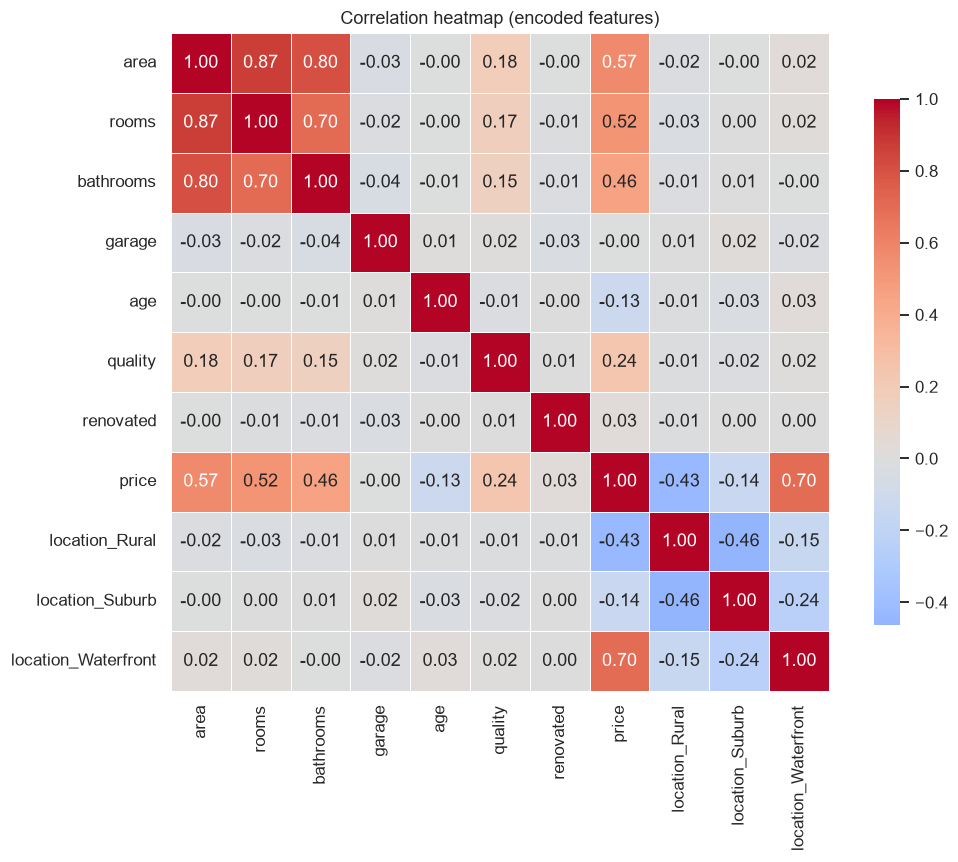

Correlation with price (sorted):

location_Waterfront    0.70
area                   0.57
rooms                  0.52
bathrooms              0.46
quality                0.24
renovated              0.03
garage                -0.00
age                   -0.13
location_Suburb       -0.14
location_Rural        -0.43


In [10]:
corr = df_encoded.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title("Correlation heatmap (encoded features)")
plt.tight_layout()
plt.savefig("../figures/02_correlation_heatmap.png", bbox_inches="tight")
plt.show()

print("Correlation with price (sorted):\n")
print(corr["price"].drop("price").sort_values(ascending=False).to_string())

**Interpretation.** The heatmap lets us spot two things:

1. **Signals** — the features most correlated with `price` (large positive/negative values in
   the `price` row/column). We expect `area` and `quality` near the top.
2. **Multicollinearity** — pairs of features that are strongly correlated with *each other*.
   `area` and `rooms` typically correlate, which we flagged in section 2. High pairwise
   correlation means their individual coefficients can be unstable / hard to interpret, which
   is exactly the problem Ridge/Lasso (°bonus section) are designed to tame.

## 5. Train / test split (80 / 20)

We hold out 20% of the data to estimate out-of-sample performance. `random_state` makes the
split reproducible.

In [11]:
X = df_encoded.drop(columns="price")
y = df_encoded["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print(f"Train price mean: ${y_train.mean():,.0f}   Test price mean: ${y_test.mean():,.0f}")

Train: (2344, 10)  Test: (586, 10)
Train price mean: $358,955   Test price mean: $356,948


### (Optional) Leakage-safe imputation pattern

For reference, the production-correct way to impute looks like this — compute the statistic on
the **training** data only, then apply it to both splits:

```python
# train_median = X_train[["area", "bathrooms", "garage", "age"]].median()
# X_train[num_cols_with_na] = X_train[num_cols_with_na].fillna(train_median)
# X_test[num_cols_with_na]  = X_test[num_cols_with_na].fillna(train_median)
```

## 6. Train a Linear Regression model

scikit-learn's [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
fits coefficients by minimising the residual sum of squares (ordinary least squares).

In [12]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

train_pred = lin_reg.predict(X_train)
test_pred = lin_reg.predict(X_test)

print("Model fitted.")
print(f"Intercept: {lin_reg.intercept_:,.2f}")

Model fitted.
Intercept: 133,514.36


## 7. Evaluate: MSE, RMSE, and R²

- **MSE** — mean squared error, in dollars² (hard to read, but the basis of the loss).
- **RMSE** — square root of MSE, back in **dollars**, so it reads as "typical error size".
- **R²** — fraction of price variance explained (1.0 = perfect, 0 = no better than the mean).

We report all three on **both** train and test to detect over/underfitting.

In [13]:
def evaluate(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name:<8} | MSE: {mse:>18,.0f} | RMSE: {rmse:>12,.0f} | MAE: {mae:>12,.0f} | R2: {r2:.4f}")
    return {"mse": mse, "rmse": rmse, "mae": mae, "r2": r2}

train_metrics = evaluate("Train", y_train, train_pred)
print("-" * 92)
test_metrics = evaluate("Test", y_test, test_pred)

Train    | MSE:        548,901,499 | RMSE:       23,429 | MAE:       17,438 | R2: 0.9651
--------------------------------------------------------------------------------------------
Test     | MSE:        586,779,059 | RMSE:       24,224 | MAE:       18,447 | R2: 0.9609


In [14]:
# The same numbers in a tidy table, and RMSE as a % of the average house price.
metrics_df = pd.DataFrame({"Train": train_metrics, "Test": test_metrics}).T
metrics_df["rmse_pct_of_mean_price"] = (metrics_df["rmse"] / y.mean() * 100).round(2)

# Present dollars as integers and R2 with 4 decimals.
print(metrics_df.to_string(
    formatters={
        "mse": "{:,.0f}".format,
        "rmse": "{:,.0f}".format,
        "mae": "{:,.0f}".format,
        "r2": "{:.4f}".format,
        "rmse_pct_of_mean_price": "{:.2f}%".format,
    }
))

              mse   rmse    mae     r2 rmse_pct_of_mean_price
Train 548,901,499 23,429 17,438 0.9651                  6.53%
Test  586,779,059 24,224 18,447 0.9609                  6.76%


**Reading the scores.**

- Train and test R² being **close together** means the model is not overfitting.
- RMSE interpreted as a percentage of the mean price gives an intuitive "typical % error".
- If test R² were far below train R², we'd suspect overfitting; if both were low, underfitting.

Remember R² is relative: a modest R² can still be useful, and for noisy real estate data an
R² in the 0.6–0.85 range is a solid linear baseline.

## 8. Actual vs. predicted prices

Each point is one held-out house: x = true price, y = predicted price. A perfect model puts
every point on the red 45° diagonal.

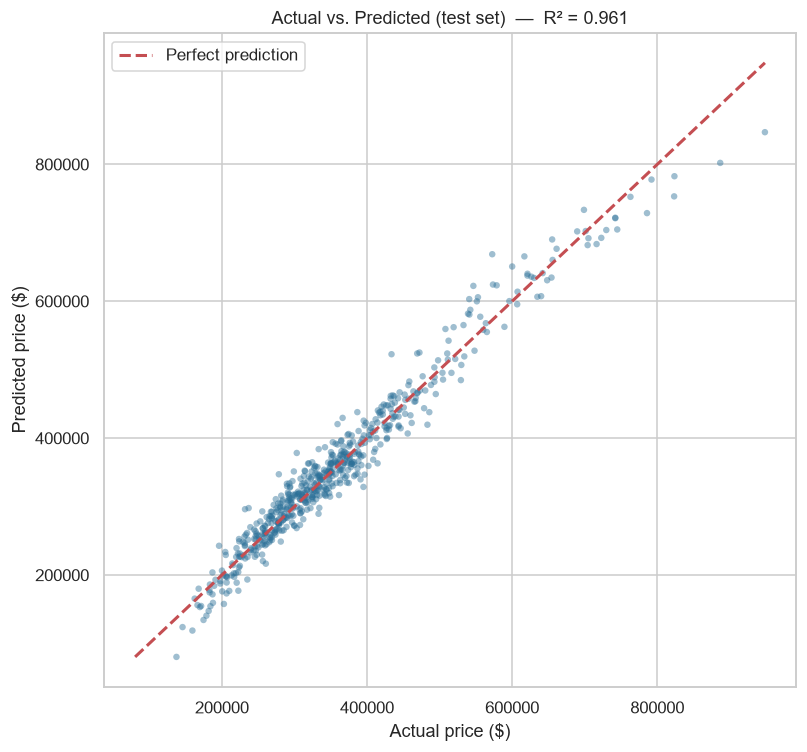

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 7))

ax.scatter(y_test, test_pred, alpha=0.45, s=18, color="#2a6f97", edgecolors="none")

lo = min(y_test.min(), test_pred.min())
hi = max(y_test.max(), test_pred.max())
ax.plot([lo, hi], [lo, hi], "r--", linewidth=2, label="Perfect prediction")

ax.set_xlabel("Actual price ($)")
ax.set_ylabel("Predicted price ($)")
ax.set_title(f"Actual vs. Predicted (test set)  —  R² = {test_metrics['r2']:.3f}")
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("../figures/03_actual_vs_predicted.png", bbox_inches="tight")
plt.show()

**Reading the plot.** Points hugging the diagonal = accurate predictions. Systematic bowing
above/below the line at the extremes would indicate the model underpredicts expensive homes
and overpredicts cheap ones — a common linear-regression limitation with skewed targets.

## 9. Residual plot

Residuals = actual − predicted. For OLS to be valid we want them to be:

- centred around **zero** (no bias),
- **randomly scattered** with no funnel or curve (constant variance / "homoscedasticity"),
- roughly **normally** distributed.

A funnel shape (residuals fanning out at higher predictions) signals heteroscedasticity.

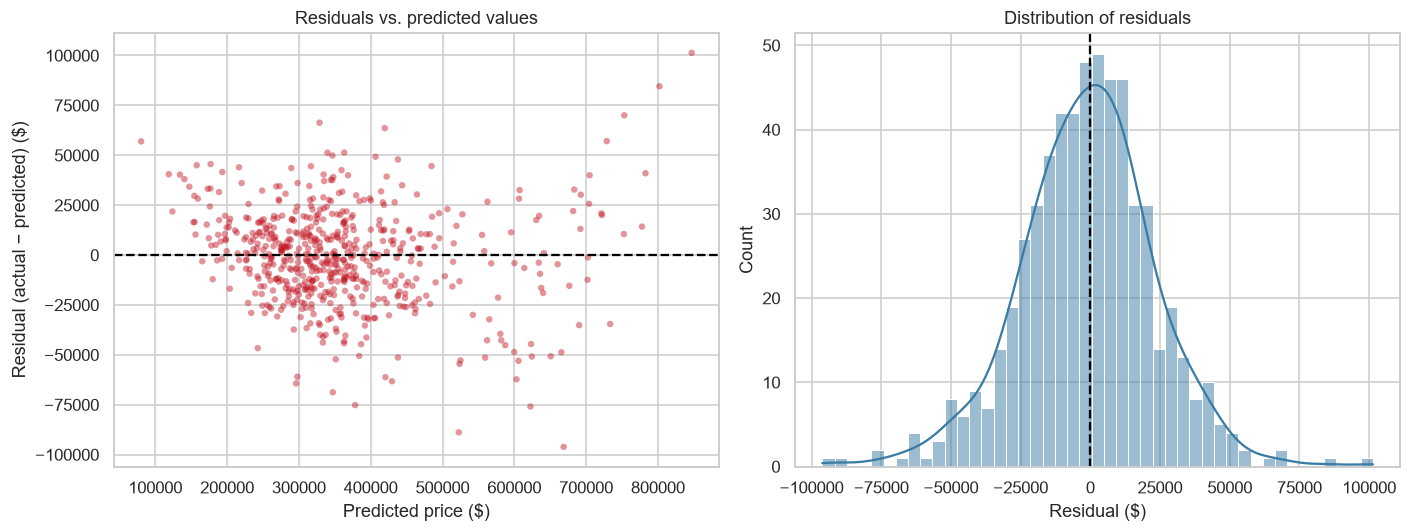

Residual mean : -1,196.22
Residual std  : 24,214.64
Skewness      : -0.097


In [16]:
residuals = y_test - test_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residuals vs predicted
axes[0].scatter(test_pred, residuals, alpha=0.45, s=18, color="#c1121f", edgecolors="none")
axes[0].axhline(0, color="black", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Predicted price ($)")
axes[0].set_ylabel("Residual (actual − predicted) ($)")
axes[0].set_title("Residuals vs. predicted values")

# Residual distribution
sns.histplot(residuals, bins=45, kde=True, ax=axes[1], color="#3a7ca5")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Residual ($)")
axes[1].set_title("Distribution of residuals")

plt.tight_layout()
plt.savefig("../figures/04_residuals.png", bbox_inches="tight")
plt.show()

print(f"Residual mean : {residuals.mean():,.2f}")
print(f"Residual std  : {residuals.std():,.2f}")
print(f"Skewness      : {residuals.skew():.3f}")

**Reading the plot.** Ideally the left panel shows a shapeless cloud centred on the dashed zero
line (random scatter, constant spread) and the right panel shows an approximately symmetric
bell around zero. Patterns to call out (and they are worth noting honestly if present):

- **Funnel** (spread grows with predicted price) → heteroscedasticity; consider log(target).
- **Curve/bow** → the true relationship is non-linear; add polynomial terms or interactions.
- **Skewed histogram** → non-normal errors; a log target often fixes it.

## 10. Coefficient analysis

Which features push price up (positive coefficients) and which pull it down (negative)?
Because our features are on different scales, we look at **both** raw coefficients (dollars per
unit) and standardised coefficients (effect per standard deviation, directly comparable).

In [17]:
coefs = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lin_reg.coef_,
})

# Standardised coefficients: multiply by the feature's std => change in $ per 1 SD of feature.
coefs["std_coef"] = coefs["coefficient"] * X.std(ddof=0).values
coefs["abs_std_coef"] = coefs["std_coef"].abs()
coefs = coefs.sort_values("std_coef", ascending=False).reset_index(drop=True)

print("Coefficients (sorted by standardised impact):\n")
print(coefs.to_string(index=False))

Coefficients (sorted by standardised impact):

            feature  coefficient   std_coef  abs_std_coef
location_Waterfront   274,824.20  71,815.66     71,815.66
               area       117.93  53,564.18     53,564.18
            quality    10,427.02  15,359.09     15,359.09
              rooms     6,322.61  10,110.33     10,110.33
          bathrooms     9,767.71   5,271.84      5,271.84
             garage     4,760.48   3,966.88      3,966.88
          renovated     6,210.28   3,025.82      3,025.82
                age      -873.98 -18,783.03     18,783.03
    location_Suburb   -51,602.52 -25,470.00     25,470.00
     location_Rural  -126,682.12 -53,231.30     53,231.30


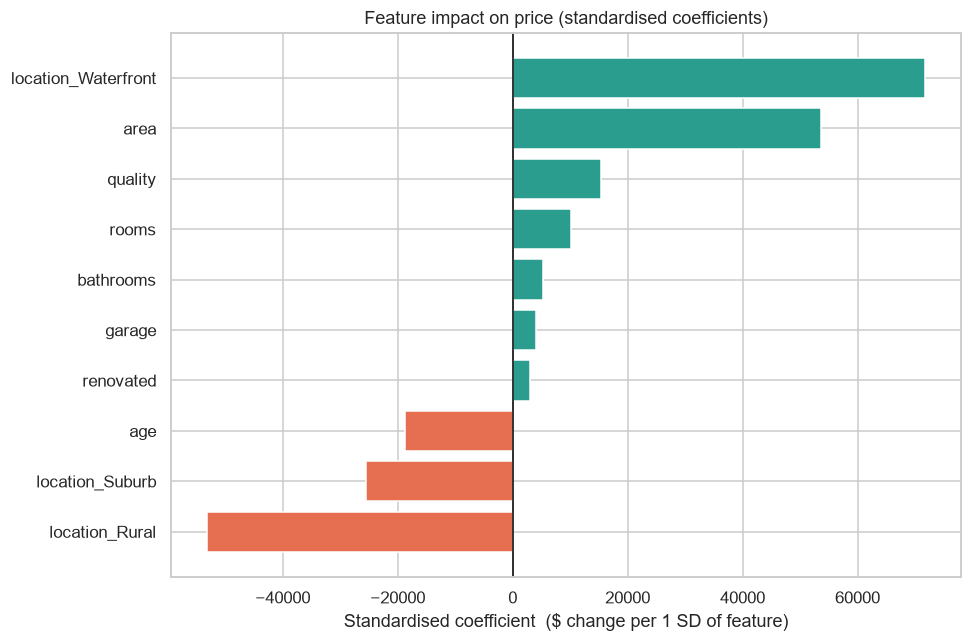

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#2a9d8f" if v >= 0 else "#e76f51" for v in coefs["std_coef"]]
ax.barh(coefs["feature"], coefs["std_coef"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Standardised coefficient  ($ change per 1 SD of feature)")
ax.set_title("Feature impact on price (standardised coefficients)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../figures/05_coefficients.png", bbox_inches="tight")
plt.show()

**Interpretation guide.**

- **Largest positive** standardised coefficient = the feature that moves price the most per
  standard deviation. Expect `area` and/or `quality` at the top.
- **Negative** coefficients mean the feature is associated with *lower* price, holding others
  constant. `age` is the usual suspect (older = cheaper).
- **Location dummies** are read relative to the dropped reference category (`Downtown`):
  a large positive `location_Waterfront` means waterfront homes sell above Downtown.
- **Caution:** correlated features share credit. If `area` and `rooms` are correlated, their
  individual coefficients can be smaller or even flip sign versus their raw correlation with
  price. That's not a bug — it's multicollinearity, and it's the motivation for the Ridge/Lasso
  comparison below.

## 11. Bonus: Linear Regression vs. Ridge & Lasso

Regularised models add a penalty on coefficient size:

- **Ridge (L2)** — shrinks coefficients, handles multicollinearity gracefully, keeps all
  features.
- **Lasso (L1)** — shrinks and can drive coefficients **exactly to zero**, doing automatic
  feature selection.

We standardise features first so the penalty is applied fairly, then compare test R² and RMSE.

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

alphas = [0.1, 1.0, 10.0, 100.0, 1000.0]

results = []
for name, estimator in [
    ("Ridge", Ridge),
    ("Lasso", Lasso),
]:
    for alpha in alphas:
        model = estimator(alpha=alpha, random_state=RANDOM_STATE, max_iter=10000)
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        results.append({
            "model": name,
            "alpha": alpha,
            "test_r2": r2_score(y_test, pred),
            "test_rmse": np.sqrt(mean_squared_error(y_test, pred)),
            "n_nonzero_coefs": int(np.sum(np.abs(model.coef_) > 1e-6)),
        })

# Baseline OLS trained on the scaled features for a like-for-like comparison.
ols_scaled = LinearRegression().fit(X_train_scaled, y_train)
ols_pred = ols_scaled.predict(X_test_scaled)
results.append({
    "model": "OLS (scaled)",
    "alpha": np.nan,
    "test_r2": r2_score(y_test, ols_pred),
    "test_rmse": np.sqrt(mean_squared_error(y_test, ols_pred)),
    "n_nonzero_coefs": int(np.sum(np.abs(ols_scaled.coef_) > 1e-6)),
})

results_df = pd.DataFrame(results).sort_values("test_r2", ascending=False).reset_index(drop=True)
print(results_df.to_string(
    formatters={
        "alpha": lambda v: "-" if pd.isna(v) else f"{v:g}",
        "test_r2": "{:.4f}".format,
        "test_rmse": "{:,.0f}".format,
    }
))

           model alpha test_r2 test_rmse  n_nonzero_coefs
0          Lasso  1000  0.9611    24,165               10
1          Ridge    10  0.9610    24,184               10
2          Lasso   100  0.9610    24,204               10
3          Ridge     1  0.9609    24,219               10
4          Lasso    10  0.9609    24,222               10
5          Ridge   0.1  0.9609    24,223               10
6   OLS (scaled)   NaN  0.9609    24,224               10
7          Lasso   0.1  0.9609    24,224               10
8          Lasso     1  0.9609    24,224               10
9          Ridge   100  0.9606    24,335               10
10         Ridge  1000  0.9073    37,308               10


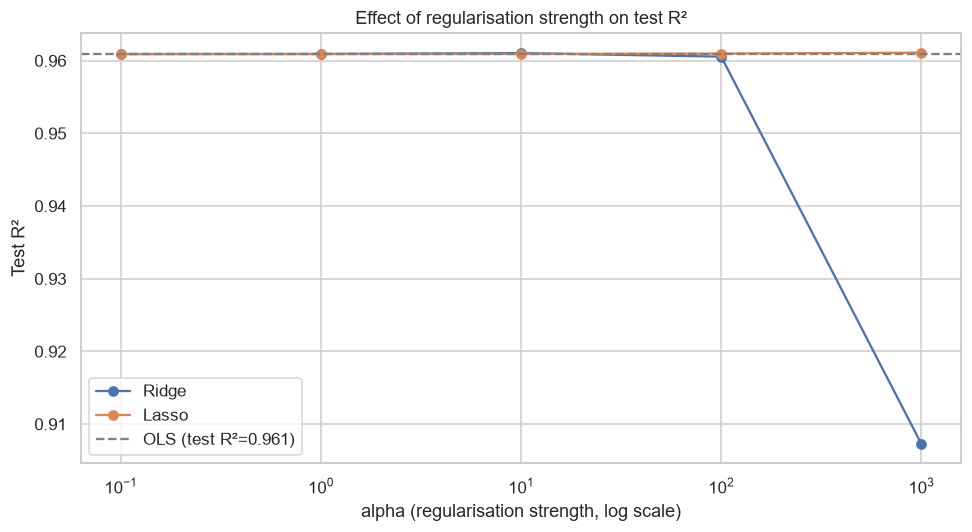

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
for name in ["Ridge", "Lasso"]:
    subset = results_df[results_df["model"] == name].sort_values("alpha")
    ax.plot(subset["alpha"], subset["test_r2"], marker="o", label=name)
ax.axhline(ols_scaled_r2 := test_metrics["r2"], color="grey", linestyle="--",
           label=f"OLS (test R\u00b2={test_metrics['r2']:.3f})")
ax.set_xscale("log")
ax.set_xlabel("alpha (regularisation strength, log scale)")
ax.set_ylabel("Test R\u00b2")
ax.set_title("Effect of regularisation strength on test R\u00b2")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/06_regularisation.png", bbox_inches="tight")
plt.show()

### Regression metrics summary (all models)

A single table comparing OLS, the best Ridge, and the best Lasso on the test set.

In [21]:
# Re-train one representative Ridge and Lasso (best alpha by test R2) for a clean summary.
best_ridge_alpha = results_df[results_df["model"] == "Ridge"].iloc[0]["alpha"]
best_lasso_alpha = results_df[results_df["model"] == "Lasso"].iloc[0]["alpha"]

summary = {
    "OLS":          (test_metrics["r2"], test_metrics["rmse"]),
    "Ridge (best)": (results_df[results_df["model"] == "Ridge"].iloc[0]["test_r2"],
                     results_df[results_df["model"] == "Ridge"].iloc[0]["test_rmse"]),
    "Lasso (best)": (results_df[results_df["model"] == "Lasso"].iloc[0]["test_r2"],
                     results_df[results_df["model"] == "Lasso"].iloc[0]["test_rmse"]),
}
summary_df = pd.DataFrame(summary, index=["Test R2", "Test RMSE"]).T
print(summary_df.to_string(
    formatters={"Test R2": "{:.4f}".format, "Test RMSE": "{:,.0f}".format}
))

             Test R2 Test RMSE
OLS           0.9609    24,224
Ridge (best)  0.9610    24,184
Lasso (best)  0.9611    24,165


**Takeaway.** On this data the models land very close together: linear regression already
captures most of the signal, and regularisation mainly guards against unstable coefficients
without a large change in test R². Lasso's `n_nonzero_coefs` column shows how aggressively it
prunes features — useful when you have hundreds of candidate predictors (as in the real Ames
dataset with ~80 features).

## 12. Conclusions & next steps

**What we did**
- Loaded and explored the data; found and quantified missing values in `area`, `bathrooms`,
  `garage`, `age`.
- Reasoned about feature relevance before modelling, then validated it with a correlation
  heatmap.
- Imputed missing values (median) and One-Hot Encoded `location` (dummy-variable-trap safe).
- Split 80/20, trained OLS Linear Regression, and evaluated with MSE, RMSE, MAE, and R² on both
  splits.
- Diagnosed the model with an actual-vs-predicted scatter and a residual plot.
- Interpreted coefficients (raw + standardised) to rank feature impact.
- Compared against Ridge and Lasso across a range of penalty strengths.

**Key findings**
- `area` and `quality` are the dominant positive drivers; `age` is the main negative one.
- Location dummies carry large effects — location is a first-class price driver.
- Train/test R² are close, so the linear model generalises rather than overfits.
- Regularisation (Ridge/Lasso) yields comparable accuracy while stabilising coefficients and,
  for Lasso, pruning unnecessary features.

**Honest limitations & next steps**
- Linear regression assumes additive, linear effects. Real prices have **interactions**
  (e.g. area × location) and non-linearities (age vs price is U-shaped for some markets).
- The target is mildly skewed; training on `log(price)` often improves residual normality and
  handles the high-price tail better.
- Multicollinearity between `area` and `rooms` muddies individual coefficients — Ridge helps.
- For the real Ames / Kaggle dataset, swap the CSV path and this same pipeline applies, with
  extra work to encode ~40 categorical columns and handle the many NA-as-a-category fields.
- Worth trying next: `PolynomialFeatures` for interactions, `GridSearchCV` to tune alpha
  properly (with cross-validation), and gradient-boosted trees as a strong non-linear baseline.